In [1]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO

fused_json_path = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json"
train_img_dir = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images"

coco = COCO(fused_json_path)
df_folds = pd.read_csv("clean_fused_folds.csv")

val_img_ids = df_folds[df_folds['fold'] == 0]['image_id'].tolist()
train_img_ids = df_folds[df_folds['fold'] != 0]['image_id'].tolist()

train_ann_ids = []
for img_id in train_img_ids:
    train_ann_ids.extend(coco.getAnnIds(imgIds=[img_id]))

print(f"Тренировочных филаментов (кропов): {len(train_ann_ids)}")

# --- 2. Класс Dataset БЕЗ КЭША (чтобы не убить память) ---
class GTCropDataset(Dataset):
    def __init__(self, coco_api, img_dir, ann_ids, transform, pad_ratio=0.20, crop_size=512):
        self.coco = coco_api
        self.img_dir = img_dir
        self.ann_ids = ann_ids
        self.transform = transform
        self.pad_ratio = pad_ratio
        self.crop_size = crop_size

    def __len__(self):
        return len(self.ann_ids)

    def __getitem__(self, idx):
        ann_id = self.ann_ids[idx]
        ann = self.coco.loadAnns([ann_id])[0]
        img_info = self.coco.loadImgs([ann['image_id']])[0]
        fname = img_info['file_name']
        
        # Читаем картинку на лету, БЕЗ сохранения в self.img_cache
        img_path = os.path.join(self.img_dir, fname)
        raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        disk_mask = raw_img > 15
        proc_img = raw_img.copy()
        if np.any(disk_mask):
            proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
        
        proc_img = proc_img.astype(np.float32) / 255.0
        img = np.stack([proc_img] * 3, axis=-1)
            
        h, w, _ = img.shape
        full_mask = self.coco.annToMask(ann)

        x, y, bw, bh = ann['bbox']
        
        cx, cy = x + bw / 2, y + bh / 2
        max_dim = max(bw, bh) * (1 + self.pad_ratio)
        x1, y1 = max(0, int(cx - max_dim / 2)), max(0, int(cy - max_dim / 2))
        x2, y2 = min(w, int(cx + max_dim / 2)), min(h, int(cy + max_dim / 2))

        crop_img = img[y1:y2, x1:x2]
        crop_mask = full_mask[y1:y2, x1:x2]

        c = cv2.resize(crop_img, (self.crop_size, self.crop_size))
        mk = cv2.resize(crop_mask, (self.crop_size, self.crop_size), interpolation=cv2.INTER_NEAREST).astype('float32')

        out = self.transform(image=c, mask=mk)
        return out['image'], out['mask'].unsqueeze(0).float()

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    ToTensorV2()
])

train_crops = GTCropDataset(coco, train_img_dir, train_ann_ids, train_tf)

# КРИТИЧНО: num_workers=0 предотвращает зависание потоков OpenCV
train_loader = DataLoader(train_crops, batch_size=8, shuffle=True, num_workers=0)

c:\Users\User\anaconda3\envs\tensorflowgpu\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


loading annotations into memory...
Done (t=0.41s)
creating index...
index created!
Тренировочных филаментов (кропов): 6579


In [2]:
import segmentation_models_pytorch as smp
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
def iou_matrix(gt_masks, pred_masks):
    if not gt_masks or not pred_masks:
        return np.zeros((len(gt_masks), len(pred_masks)), dtype=np.float32)
    G = torch.from_numpy(np.stack([m.ravel() for m in gt_masks])).to(DEVICE).half()
    P = torch.from_numpy(np.stack([m.ravel() for m in pred_masks])).to(DEVICE).half()
    inter = (G @ P.t()).float()
    union = G.sum(1).float()[:, None] + P.sum(1).float()[None, :] - inter
    out = torch.where(union > 0, inter / union, torch.zeros_like(inter)).cpu().numpy()
    del G, P
    return out


class PQAccumulator:
    def __init__(self, thr=0.5):
        self.thr, self.tp_ious, self.fp, self.fn = thr, [], 0, 0

    def add(self, iou):
        n_gt, n_pred = iou.shape
        if n_gt == 0:
            self.fp += n_pred; return
        if n_pred == 0:
            self.fn += n_gt; return
        hit = iou > self.thr
        self.tp_ious.extend(iou[hit].tolist())
        self.fp += int((hit.sum(0) == 0).sum())
        self.fn += int((hit.sum(1) == 0).sum())

    def result(self):
        tp = len(self.tp_ious)
        den = tp + 0.5 * self.fp + 0.5 * self.fn
        sq = sum(self.tp_ious) / tp if tp else 0.0
        dq = tp / den if den else 0.0
        return dict(PQ=dq * sq, DQ=dq, SQ=sq, TP=tp, FP=self.fp, FN=self.fn)

In [4]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import segmentation_models_pytorch as smp

In [5]:
# --- 1. Инициализация мощного сегментатора ---
print("Загрузка U-Net с энкодером EfficientNet-B4...")
seg_model_heavy = smp.Unet(
    encoder_name='efficientnet-b4', 
    encoder_weights='imagenet', # Обязательно используем предобученные веса
    in_channels=3, 
    classes=1
).to(DEVICE)

# --- 2. Настройки обучения ---
# Увеличим до 15 эпох, так как тяжелой сети нужно чуть больше времени на "раскачку"
EPOCHS = 15 
optimizer = optim.AdamW(seg_model_heavy.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True) # Твой лосс

print(f"Запуск обучения тяжелого U-Net на {EPOCHS} эпох...")
seg_model_heavy.train()

# --- 3. Цикл обучения ---
for epoch in range(EPOCHS):
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{EPOCHS}")
    
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            logits = seg_model_heavy(x)
            loss = criterion(logits, y)
            
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    scheduler.step() 
    print(f"Средний Loss: {total_loss/len(train_loader):.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

Загрузка U-Net с энкодером EfficientNet-B4...


Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to C:\Users\User/.cache\torch\hub\checkpoints\efficientnet-b4-6ed6700e.pth
100%|██████████| 74.4M/74.4M [00:04<00:00, 18.8MB/s]


Запуск обучения тяжелого U-Net на 15 эпох...


Эпоха 1/15: 100%|██████████| 823/823 [12:24<00:00,  1.10it/s, loss=0.3843]


Средний Loss: 0.4053 | LR: 0.000297


...

Средний Loss: 0.2806 | LR: 0.000013


Эпоха 14/15: 100%|██████████| 823/823 [10:58<00:00,  1.25it/s, loss=0.2198]


Средний Loss: 0.2790 | LR: 0.000003


Эпоха 15/15: 100%|██████████| 823/823 [10:58<00:00,  1.25it/s, loss=0.3868]

Средний Loss: 0.2784 | LR: 0.000000


In [6]:
# --- 4. Сохранение ---
# Сохраняем под новым именем, чтобы не затереть старый рабочий файл!
SAVE_PATH = r"X:\Desktop\kaggle\solar_project_cv\models\best_seg_effnetb4.pth"
torch.save(seg_model_heavy.state_dict(), SAVE_PATH)
print(f"Обучение завершено! Веса сохранены в: {SAVE_PATH}")

Обучение завершено! Веса сохранены в: X:\Desktop\kaggle\solar_project_cv\models\best_seg_effnetb4.pth


In [14]:
import os
import cv2
import time
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from pycocotools.coco import COCO
from ultralytics import YOLO
import segmentation_models_pytorch as smp


BASE_DIR = r"X:\Desktop\kaggle\solar_project_cv"
IMG_DIR = os.path.join(BASE_DIR, r"notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images")
JSON_PATH = os.path.join(BASE_DIR, r"notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json")


SEG_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\best_seg_effnetb4.pth"
YOLO_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\yolo_detector\weights\best.pt"
FOLDS_CSV = "clean_fused_folds.csv"


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CFG_CROP_SIZE = 512
CFG_DET_IMGSZ = 1280

# === 2. ИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ ===
print("Загрузка моделей...")
det_model = YOLO(YOLO_WEIGHTS)

# Новый энкодер efficientnet-b4
seg_model = smp.Unet(encoder_name='efficientnet-b4', in_channels=3, classes=1).to(DEVICE)
seg_model.load_state_dict(torch.load(SEG_WEIGHTS, map_location=DEVICE))
seg_model.eval()

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

# === 3. ФУНКЦИИ ИНФЕРЕНСА И МЕТРИК ===
def cache_predictions_fused(image_path, det_model, seg_model, device, pad_ratio=0.20):
    raw_img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if raw_img is None: return [], (0, 0)
    if len(raw_img.shape) > 2: raw_img = raw_img[:, :, 0]
    h, w = raw_img.shape[:2]
    
    disk_mask = raw_img > 15
    proc_img = raw_img.copy()
    if np.any(disk_mask):
        proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
    fused_img = np.stack([proc_img.astype(np.float32) / 255.0] * 3, axis=-1)

    r = det_model.predict(str(image_path), imgsz=CFG_DET_IMGSZ, conf=0.05, verbose=False)[0]
    boxes, confs = r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy()

    if len(boxes) == 0: return [], (h, w)

    crops, metas = [], []
    for (x1, y1, x2, y2), c in zip(boxes, confs):
        bw, bh = x2 - x1, y2 - y1
        pw, ph = bw * pad_ratio, bh * pad_ratio
        cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
        cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
        if cx2 <= cx1 + 1 or cy2 <= cy1 + 1: continue
            
        crop = cv2.resize(fused_img[cy1:cy2, cx1:cx2], (CFG_CROP_SIZE, CFG_CROP_SIZE))
        crops.append(crop)
        metas.append((float(c), (cx1, cy1, cx2, cy2)))

    out = []
    # Защита от расчета градиентов для экономии памяти
    with torch.no_grad():
        for i in range(0, len(crops), 8):
            batch = torch.from_numpy(np.stack(crops[i:i+8])).permute(0, 3, 1, 2).float().to(device)
            with torch.amp.autocast('cuda'):
                probs = torch.sigmoid(seg_model(batch)).float().cpu().numpy()[:, 0]
            for p, (c, box) in zip(probs, metas[i:i+8]):
                cx1, cy1, cx2, cy2 = box
                probs_resized = cv2.resize(p, (cx2 - cx1, cy2 - cy1)).astype('float16')
                out.append({'conf': c, 'box': box, 'probs': probs_resized})
    return out, (h, w)

def paint_panoptic(cached, shape, conf_t, mask_t, min_area=30):
    h, w = shape
    items = sorted([it for it in cached if it['conf'] >= conf_t], key=lambda d: -d['conf'])
    occupied = np.zeros((h, w), dtype=bool)
    masks = []
    for it in items:
        cx1, cy1, cx2, cy2 = it['box']
        m = np.zeros((h, w), dtype=bool)
        m[cy1:cy2, cx1:cx2] = it['probs'].astype('float32') > mask_t
        m &= ~occupied
        if m.sum() > min_area:
            occupied |= m
            masks.append(m)
    return masks

def iou_matrix(gt_masks, pred_masks):
    if not gt_masks or not pred_masks:
        return np.zeros((len(gt_masks), len(pred_masks)), dtype=np.float32)
    G = torch.from_numpy(np.stack([m.ravel() for m in gt_masks])).to(DEVICE).half()
    P = torch.from_numpy(np.stack([m.ravel() for m in pred_masks])).to(DEVICE).half()
    inter = (G @ P.t()).float()
    union = G.sum(1).float()[:, None] + P.sum(1).float()[None, :] - inter
    out = torch.where(union > 0, inter / union, torch.zeros_like(inter)).cpu().numpy()
    del G, P; return out

class PQAccumulator:
    def __init__(self, thr=0.5):
        self.thr, self.tp_ious, self.fp, self.fn = thr, [], 0, 0
    def add(self, iou):
        n_gt, n_pred = iou.shape
        if n_gt == 0: self.fp += n_pred; return
        if n_pred == 0: self.fn += n_gt; return
        hit = iou > self.thr
        self.tp_ious.extend(iou[hit].tolist())
        self.fp += int((hit.sum(0) == 0).sum())
        self.fn += int((hit.sum(1) == 0).sum())
    def result(self):
        tp = len(self.tp_ious)
        den = tp + 0.5 * self.fp + 0.5 * self.fn
        sq = sum(self.tp_ious) / tp if tp else 0.0
        dq = tp / den if den else 0.0
        return dict(PQ=dq * sq, DQ=dq, SQ=sq, TP=tp, FP=self.fp, FN=self.fn)

def gt_masks_by_annotator(fname, coco_api, photo_to_ids):
    return {iid: [coco_api.annToMask(a).astype(bool) for a in coco_api.loadAnns(coco_api.getAnnIds(imgIds=[iid]))]
            for iid in photo_to_ids.get(fname, [])}

# === 4. ЗАПУСК GRID SEARCH ===
df_folds = pd.read_csv(FOLDS_CSV)
val_photos = df_folds[df_folds['fold'] == 0]['file_name'].unique()[:40] 

coco = COCO(JSON_PATH)
photo_to_ids = {}
for iid in coco.imgs:
    photo_to_ids.setdefault(coco.imgs[iid]['file_name'], []).append(iid)

conf_grid = [0.15, 0.20, 0.25, 0.30]
mask_grid = [0.40, 0.50, 0.60]
grid = [(c, m) for c in conf_grid for m in mask_grid]
accs = {k: PQAccumulator(thr=0.5) for k in grid}

print(f"\nТестируем {len(grid)} комбинаций на {len(val_photos)} изображениях...")
t0 = time.time()

for n, fname in enumerate(val_photos, 1):
    img_path = os.path.join(IMG_DIR, fname)
    cached, shape = cache_predictions_fused(img_path, det_model, seg_model, DEVICE)
    gts = gt_masks_by_annotator(fname, coco, photo_to_ids)
    
    for combo in grid:
        preds = paint_panoptic(cached, shape, *combo)
        for masks in gts.values():
            accs[combo].add(iou_matrix(masks, preds))
            
    if n % 10 == 0:
        print(f"  {n}/{len(val_photos)} обработано · {time.time()-t0:.0f}s")

# Вывод результатов
results = []
for c, m in grid:
    res = accs[(c, m)].result()
    results.append({'conf': c, 'mask_thr': m, **res})

sweep = pd.DataFrame(results).sort_values('PQ', ascending=False).reset_index(drop=True)
print("\n=== ЛУЧШИЕ РЕЗУЛЬТАТЫ (YOLO + EfficientNet-B4) ===")
display(sweep.head(5))

Загрузка моделей...


C:\Users\User\AppData\Local\Temp\ipykernel_792\3844712658.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  seg_model.load_state_dict(torch.load(SEG_WEIGHTS, map_location

loading annotations into memory...
Done (t=0.28s)
creating index...
index created!

Тестируем 12 комбинаций на 40 изображениях...
  10/40 обработано · 23s
  20/40 обработано · 60s
  30/40 обработано · 89s
  40/40 обработано · 117s

=== ЛУЧШИЕ РЕЗУЛЬТАТЫ (YOLO + EfficientNet-B4) ===


,conf,mask_thr,PQ,DQ,SQ,TP,FP,FN
0,0.30,0.5,0.356726,0.555066,0.642673,252,167,237
1,0.30,0.4,0.354939,0.551648,0.643414,251,170,238
2,0.30,0.6,0.352030,0.545655,0.645151,248,172,241
3,0.25,0.5,0.350068,0.545838,0.641341,259,201,230
4,0.25,0.4,0.348382,0.542587,0.642075,258,204,231


In [4]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from ultralytics import YOLO
import segmentation_models_pytorch as smp
import pycocotools.mask as maskUtils

# --- 1. ПУТИ ДЛЯ KAGGLE ---
TEST_IMG_DIR = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"
# ВНИМАНИЕ: Укажи пути к загруженным файлам с весами в твоем Kaggle-датасете
YOLO_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\yolo_detector\weights\best.pt"
SEG_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\best_seg_effnetb4.pth" 

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Новые лучшие пороги для EfficientNet-B4
BEST_CONF = 0.30
BEST_MASK_THR = 0.50 

CFG_CROP_SIZE = 512
CFG_DET_IMGSZ = 1280
PAD_RATIO = 0.20

# --- 2. ИНИЦИАЛИЗАЦИЯ ---
det_model = YOLO(YOLO_WEIGHTS)

# Инициализируем U-Net с новым энкодером
seg_model = smp.Unet(encoder_name='efficientnet-b4', in_channels=3, classes=1).to(DEVICE)
seg_model.load_state_dict(torch.load(SEG_WEIGHTS, map_location=DEVICE))
seg_model.eval()

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

def coco_rle_encode(mask):
    rle = maskUtils.encode(np.asfortranarray(mask.astype(np.uint8)))
    return rle['counts'].decode('utf-8')

# --- 3. ИНФЕРЕНС И ФОРМИРОВАНИЕ САБМИТА ---
test_images = sorted(os.listdir(TEST_IMG_DIR))
submission_data = []
for fname in test_images:
    # ЗАЩИТА: Пропускаем папки и любые другие файлы, кроме картинок
    if not (fname.endswith('.jpeg') or fname.endswith('.jpg')):
        continue
        
    img_path = os.path.join(TEST_IMG_DIR, fname)
    raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if len(raw_img.shape) > 2: raw_img = raw_img[:, :, 0]
    h, w = raw_img.shape[:2]
    
    # Fused preprocessing
    disk_mask = raw_img > 15
    proc_img = raw_img.copy()
    if np.any(disk_mask):
        proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
    fused_img = np.stack([proc_img.astype(np.float32) / 255.0] * 3, axis=-1)

    # Детекция YOLO
    r = det_model.predict(img_path, imgsz=CFG_DET_IMGSZ, conf=BEST_CONF, verbose=False)[0]
    boxes, confs = r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy()

    occupied = np.zeros((h, w), dtype=bool)
    
    filename_base = fname.rsplit('.', 1)[0]
    filament_counter = 1

    sorted_indices = np.argsort(-confs)
    for idx in sorted_indices:
        x1, y1, x2, y2 = boxes[idx]
        bw, bh = x2 - x1, y2 - y1
        pw, ph = bw * PAD_RATIO, bh * PAD_RATIO
        cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
        cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
        
        if cx2 <= cx1 + 1 or cy2 <= cy1 + 1: continue
            
        crop = cv2.resize(fused_img[cy1:cy2, cx1:cx2], (CFG_CROP_SIZE, CFG_CROP_SIZE))
        batch = torch.from_numpy(crop).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        
        with torch.no_grad(), torch.amp.autocast('cuda'):
            prob = torch.sigmoid(seg_model(batch)).float().cpu().numpy()[0, 0]
            
        prob_resized = cv2.resize(prob, (cx2 - cx1, cy2 - cy1))
        
        m = np.zeros((h, w), dtype=bool)
        m[cy1:cy2, cx1:cx2] = prob_resized > BEST_MASK_THR
        m &= ~occupied
        
        if m.sum() > 30:
            occupied |= m
            submission_data.append({
                'filament_id': f"{filename_base}_{filament_counter}", 
                'segmentation_rle': coco_rle_encode(m)
            })
            filament_counter += 1

C:\Users\User\AppData\Local\Temp\ipykernel_25376\933464362.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  seg_model.load_state_dict(torch.load(SEG_WEIGHTS, map_locatio

In [5]:
# Сохранение
df_sub = pd.DataFrame(submission_data)

In [6]:
df_sub.head()

,filament_id,segmentation_rle
0,20110120105534Ch_1,[inP23lo12`NLRSN5il1MYSNObN1Rn1OmQN0_1OZO2bl13...
1,20110120105534Ch_2,c`Ti21oo11M4N0oPNMUn14jQNMWn13gQNNZn12dQNN\n12...
2,20110130110334Ch_1,d_Re2:eo12O1^PNE\o1a0O1001NkPNAm2Nfh1`0[TNEn2K...
3,20110130110334Ch_2,enPg24lo12N00001O0001O2MVPNOlo11N100O2\PNLZo14...
4,20110214175414Mh_1,hY_g26io18YPNGWo1c0N101N1O2N0QOTOkRNm0Tm1UOjRN...


In [3]:
df_sub.head()

""


In [7]:
df_sub.to_csv('submission6.csv', index=False)
print(f"submission.csv успешно создан! Найдено филаментов: {len(df_sub)}")

submission.csv успешно создан! Найдено филаментов: 1495


29/09

In [ ]:
SEG_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\best_seg.pth"

det_model = YOLO(YOLO_WEIGHTS)
seg_model = smp.Unet(encoder_name='resnet34', in_channels = 3, classes = 1).to(DEVICE)
seg_model.load_state_dict(torch.load(SEG_WEIGHTS, map_location=DEVICE))
seg_model.eval()

0.3

In [9]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8) )
morph_kernel = np.ones((5,5), np.uint8)

def coco_rle_encode(mask):
    rle= maskUtils.encode(np.asfortranarray(mask.astype(np.uint8)))
    return rle['counts'].decode('utf-8')

In [ ]:
test_images = sorted(os.listdir(TEST_IMG_DIR))
submission_data = []

for fname in test_images:
    if not (fname.endswith('.jpeg') or fname.endswith('.jpg')):
        continue

    img_path = os.path.join(TEST_IMG_DIR, fname)
    raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if len(raw_img.shape)>2: raw_img = raw_img[:, :, 0]
    h, w = raw_img.shape[:2]

    disk_mask = raw_img>15
    proc_img = raw_img.copy()
    if np.any(disk_mask):
        #we here discriminatively apply clahe only for specific regions in the image
        proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
    fused_img = np.stack([proc_img.astype(np.float32)/255.0]*3, axis=-1)
    r = det_model.predict(img_path, imgsz=CFG_DET_IMGSZ, conf=BEST_CONF, verbose=False)[0]
    boxes, confs = r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy()

    occupied = np.zeros((h, w), dtype=bool)
    filename_base = fname.rsplit('.', 1)[0]
    filament_counter = 1
    # negative sign in argsort sorts it in descending order 
    sorted_indices = np.argsort(-confs)
    for idx in sorted_indices:
        x1, y1, x2, y2 = boxes[idx]
        bw, bh = x2 - x1, y2 - y1
        pw, ph = bw * PAD_RATIO, bh * PAD_RATIO
        #clamp crop coordinates
        cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
        cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
        
        if cx2 <= cx1 + 1 or cy2 <= cy1 + 1: continue
            
        crop = cv2.resize(fused_img[cy1:cy2, cx1:cx2], (CFG_CROP_SIZE, CFG_CROP_SIZE))
        batch = torch.from_numpy(crop).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        
        with torch.no_grad(), torch.amp.autocast('cuda'):
            # TTA: Оригинал
            prob_orig = torch.sigmoid(seg_model(batch)).float().cpu().numpy()[0, 0]
            
            # TTA: Горизонтальное отражение
            batch_h = torch.flip(batch, [3])
            prob_h = torch.sigmoid(seg_model(batch_h)).float().cpu().numpy()[0, 0]
            prob_h = np.fliplr(prob_h)
            
            # TTA: Вертикальное отражение
            batch_v = torch.flip(batch, [2])
            prob_v = torch.sigmoid(seg_model(batch_v)).float().cpu().numpy()[0, 0]
            prob_v = np.flipud(prob_v)
            
            # Усреднение
            prob = (prob_orig + prob_h + prob_v) / 3.0
            
        prob_resized = cv2.resize(prob, (cx2 - cx1, cy2 - cy1))
        
        # Бинаризация
        local_mask = (prob_resized > BEST_MASK_THR).astype(np.uint8)
        
        # Морфологическое замыкание (убираем дырки внутри)
        local_mask = cv2.morphologyEx(local_mask, cv2.MORPH_CLOSE, morph_kernel)
        
        m = np.zeros((h, w), dtype=bool)
        m[cy1:cy2, cx1:cx2] = local_mask.astype(bool)
        m &= ~occupied
        
        if m.sum() > 30:
            occupied |= m
            submission_data.append({
                'filament_id': f"{filename_base}_{filament_counter}", 
                'segmentation_rle': coco_rle_encode(m)
            })
            filament_counter += 1


In [11]:
df_sub = pd.DataFrame(submission_data)

In [12]:
df_sub.head()

,filament_id,segmentation_rle
0,20110120105534Ch_1,]ilP21mo12O2O1]NKYSN7el1I[SN1XO1dl11nTN1Qk1NoT...
1,20110120105534Ch_2,c`Ti21oo11L5oPNJUn15jQNMUn14jQNMWn14fQNM[n12dQ...
2,20110130110334Ch_1,c_Re2;do12O5K1O11O0OkPNBl2Mgh1`0[TNFm2Jih1`0XT...
3,20110130110334Ch_2,enPg24lo12N00001O0001O210NO00001\PNK[o15dPNOZo...
4,20110214175414Mh_1,hY_g29eo1<E2N2O1N1O1O1O1POUOjRNj0Wm1WOeRNh0`m1...


In [13]:
df_sub.to_csv('submission_tta7.csv', index=False)
print(f"submission_tta.csv успешно создан! Найдено филаментов: {len(df_sub)}")

submission_tta.csv успешно создан! Найдено филаментов: 1494


In [29]:
class SolarFilamentCropDataset(Dataset):
    def __init__(self, df_images, coco_data, img_dir, transform=None, pad_ratio=0.20):
        self.img_dir = img_dir
        self.transform = transform
        self.pad_ratio = pad_ratio
        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))

        valid_img_ids = set(df_images['id'].values)
        self.crops = []
        
        for ann in coco_data['annotations']:
            if ann['image_id'] in valid_img_ids:
                img_info = next(item for item in coco_data['images'] if item["id"] == ann['image_id'])
                self.crops.append({
                    'file_name': img_info['file_name'],
                    'bbox': ann['bbox'], 
                    'segmentation': ann['segmentation']
                })

    def __len__(self):
        return len(self.crops) 

    def __getitem__(self, idx):
        item = self.crops[idx]
        img_path = os.path.join(self.img_dir, item['file_name'])

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None: raise FileNotFoundError(f"Not found: {img_path}")
        
        # --- ИСПРАВЛЕНИЕ ЗДЕСЬ ---
        # Защита от лишних размерностей (например, если shape = (H, W, 1))
        if len(image.shape) > 2:
            image = image[:, :, 0]
        h, w = image.shape[:2]
        # -------------------------

        disk_mask = image > 15
        proc_img = image.copy()
        if np.any(disk_mask):
            proc_img[disk_mask] = self.clahe.apply(image)[disk_mask]
        
        proc_img = proc_img.astype(np.float32) / 255.0
        proc_img = np.stack([proc_img] * 3, axis=-1)

        mask = np.zeros((h, w), dtype=np.float32)
        for poly in item['segmentation']:
            pts = np.array(poly, dtype=np.int32).reshape((-1, 2))
            cv2.fillPoly(mask, [pts], 1.0)

        x, y, bw, bh = item['bbox']
        pw, ph = bw * self.pad_ratio, bh * self.pad_ratio
        
        cx1, cy1 = max(0, int(x - pw)), max(0, int(y - ph))
        cx2, cy2 = min(w, int(x + bw + pw)), min(h, int(y + bh + ph))

        crop_img = proc_img[cy1:cy2, cx1:cx2]
        crop_mask = mask[cy1:cy2, cx1:cx2]

        if self.transform:
            augmented = self.transform(image=crop_img, mask=crop_mask)
            crop_img = augmented['image']
            crop_mask = augmented['mask']
            
        if crop_mask.ndim == 2:
            crop_mask = crop_mask.unsqueeze(0)

        return crop_img, crop_mask

In [17]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import json

# Трансформации для тренировки (с аугментациями)
def get_train_transforms(img_size=512):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        ToTensorV2()
    ])

# Трансформации для валидации (СТРОГО без искажений, только ресайз)
def get_val_transforms(img_size=512):
    return A.Compose([
        A.Resize(img_size, img_size),
        ToTensorV2()
    ])

c:\Users\User\anaconda3\envs\tensorflowgpu\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [14]:
from sklearn.model_selection import GroupKFold

# 1. Твоя функция
def create_grouped_folds(coco_json_path, n_splits=5):
    with open(coco_json_path, "r") as f:
        coco_data = json.load(f)

    df_images = pd.DataFrame(coco_data["images"])
    df_images['group_date'] = df_images['file_name'].apply(lambda x: x[:8])

    gkf = GroupKFold(n_splits=n_splits)
    df_images["fold"] = -1

    for fold, (train_idx, val_idx) in enumerate(gkf.split(df_images, groups=df_images['group_date'])):
        df_images.loc[val_idx, 'fold'] = fold
        
    print(f"Dataset split into {n_splits} folds based on observation dates.")
    print(df_images['fold'].value_counts().sort_index())
    return df_images, coco_data

In [ ]:
fused_json_path = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json"
df_images, coco_data = create_grouped_folds(fused_json_path, n_splits=5)
train_img_dir = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images"
SAVE_DIR = r"X:\Desktop\kaggle\solar_project_cv\models"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 12


In [16]:
from albumentations.pytorch import ToTensorV2
import json

In [17]:
df_images, coco_data = create_grouped_folds(fused_json_path, n_splits=5)
NUM_FOLDS = df_images['fold'].nunique()

Dataset split into 5 folds based on observation dates.
fold
0    142
1    142
2    141
3    141
4    141
Name: count, dtype: int64


In [27]:
import os
import json
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import segmentation_models_pytorch as smp
from tqdm import tqdm
from torch.utils.data import DataLoader

In [31]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import segmentation_models_pytorch as smp



# --- 2. ЦИКЛ ОБУЧЕНИЯ ПО ФОЛДАМ ---
for current_fold in range(NUM_FOLDS):
    print(f"\n{'='*40}\nЗАПУСК ОБУЧЕНИЯ: ФОЛД {current_fold} ИЗ {NUM_FOLDS-1}\n{'='*40}")
    
    # Разделение данных
    # -----------------------------------------------------------
    # ВСТАВЬ СЮДА СВОЙ КОД СОЗДАНИЯ train_loader И val_loader
    # Делим на Train и Val динамически для текущего фолда
    df_train = df_images[df_images["fold"] != current_fold].reset_index(drop=True)
    df_val = df_images[df_images["fold"] == current_fold].reset_index(drop=True)

    # Создаем Dataset объекты
    train_dataset = SolarFilamentCropDataset(
        df_images=df_train,
        coco_data=coco_data,
        img_dir=train_img_dir,
        transform=get_train_transforms(img_size=512),
        pad_ratio=0.20 # Не забываем про отступ!
    )

    val_dataset = SolarFilamentCropDataset(
        df_images=df_val,
        coco_data=coco_data,
        img_dir=train_img_dir,
        transform=get_val_transforms(img_size=512),
        pad_ratio=0.20
    )

    # DataLoader (num_workers=0 это безопасный вариант для Windows)
    train_loader = DataLoader(
        train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=8, shuffle=False, num_workers=0, pin_memory=True
    )
    # Используй train_df и val_df для инициализации датасетов
    # -----------------------------------------------------------
    
    # Инициализация чистой модели для текущего фолда
    model = smp.Unet(
        encoder_name='resnet34', 
        encoder_weights='imagenet', 
        in_channels=3, 
        classes=1
    ).to(DEVICE)
    
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
    
    best_val_loss = float('inf')
    save_path = os.path.join(SAVE_DIR, f"best_seg_resnet34_fold_{current_fold}.pth")
    
    # Цикл эпох
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        
        pbar = tqdm(train_loader, desc=f"Эпоха {epoch+1}/{EPOCHS}")
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                logits = model(x)
                loss = criterion(logits, y)
                
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
            
        scheduler.step()
        
        # Валидация
        model.eval()
        val_loss = 0
        with torch.no_grad(), torch.amp.autocast('cuda'):
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(DEVICE), y_val.to(DEVICE)
                val_logits = model(x_val)
                val_loss += criterion(val_logits, y_val).item()
        
        val_loss /= len(val_loader)
        print(f"Fold {current_fold} | Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")
        
        # Сохранение лучших весов для конкретного фолда
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  [*] Лучшая модель фолда {current_fold} сохранена (Loss: {best_val_loss:.4f})!")


ЗАПУСК ОБУЧЕНИЯ: ФОЛД 0 ИЗ 4


Эпоха 1/12: 100%|██████████| 823/823 [10:05<00:00,  1.36it/s, loss=0.4936]


Fold 0 | Epoch 1 | Train Loss: 0.3220 | Val Loss: 0.7313
  [*] Лучшая модель фолда 0 сохранена (Loss: 0.7313)!


Эпоха 2/12: 100%|██████████| 823/823 [09:49<00:00,  1.40it/s, loss=0.5754]


Fold 0 | Epoch 2 | Train Loss: 0.3449 | Val Loss: 0.6203
  [*] Лучшая модель фолда 0 сохранена (Loss: 0.6203)!


...

Fold 4 | Epoch 10 | Train Loss: 0.2535 | Val Loss: 0.2534


Эпоха 11/12: 100%|██████████| 828/828 [09:53<00:00,  1.39it/s, loss=0.2536]


Fold 4 | Epoch 11 | Train Loss: 0.2464 | Val Loss: 0.2410


Эпоха 12/12: 100%|██████████| 828/828 [09:57<00:00,  1.39it/s, loss=0.2168]


Fold 4 | Epoch 12 | Train Loss: 0.2359 | Val Loss: 0.2352


In [5]:
MODELS_DIR = r"X:\Desktop\kaggle\solar_project_cv\models"

seg_models = []
for i in range(5):
    model = smp.Unet(encoder_name='resnet34', in_channels=3, classes=1).to(DEVICE)
    model_path = os.path.join(MODELS_DIR, f"best_seg_resnet34_fold_{i}.pth")
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    seg_models.append(model)

print(f"Успешно загружено {len(seg_models)} моделей для ансамбля.")

C:\Users\User\AppData\Local\Temp\ipykernel_28704\1032567430.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DEV

Успешно загружено 5 моделей для ансамбля.


In [6]:
det_model = YOLO(YOLO_WEIGHTS)

NameError: name 'YOLO' is not defined

In [ ]:
test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.jpeg', '.jpg', '.png'))])

In [46]:
submission_data = []
for fname in tqdm(test_files, desc="Обработка тестовых изображений"):
    img_path = os.path.join(TEST_IMG_DIR, fname)
    image_id = os.path.splitext(fname)[0]
    
    raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if raw_img is None: continue
    if len(raw_img.shape) > 2: raw_img = raw_img[:, :, 0]
    h, w = raw_img.shape[:2]
    
    disk_mask = raw_img > 15
    proc_img = raw_img.copy()
    if np.any(disk_mask):
        proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
        
    fused_img = proc_img.astype(np.float32) / 255.0
    fused_img = np.stack([fused_img] * 3, axis=-1)
    
    r = det_model.predict(img_path, imgsz=1280, conf=0.30, verbose=False)[0]
    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    
    # 1. Сортируем рамки по уверенности YOLO (по убыванию)
    sorted_indices = np.argsort(-confs)
    boxes = boxes[sorted_indices]
    
    # 2. Карта занятых пикселей для предотвращения наложений (Overlap)
    occupied_pixels = np.zeros((h, w), dtype=np.uint8)
    
    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        bw, bh = x2 - x1, y2 - y1
        pw, ph = bw * PAD_RATIO, bh * PAD_RATIO
        
        cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
        cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
        
        crop = fused_img[cy1:cy2, cx1:cx2]
        crop_resized = cv2.resize(crop, (CFG_CROP_SIZE, CFG_CROP_SIZE))
        
        batch = torch.from_numpy(crop_resized).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        
        probs = []
        with torch.no_grad(), torch.amp.autocast('cuda'):
            for model in seg_models:
                p = torch.sigmoid(model(batch)).float().cpu().numpy()[0, 0]
                probs.append(p)
        
        ensemble_prob = np.mean(probs, axis=0)
        pred_mask_resized = (ensemble_prob > BEST_MASK_THR).astype(np.uint8)
        
        crop_h, crop_w = cy2 - cy1, cx2 - cx1
        pred_mask_original_size = cv2.resize(pred_mask_resized, (crop_w, crop_h), interpolation=cv2.INTER_NEAREST)
        
        single_filament_mask = np.zeros((h, w), dtype=np.uint8)
        single_filament_mask[cy1:cy2, cx1:cx2] = pred_mask_original_size
        
        # --- ФИЛЬТРАЦИЯ НАЛОЖЕНИЙ (ANTI-OVERLAP) ---
        # Вычитаем те пиксели, которые уже были закрашены более уверенными масками ранее
        # single_filament_mask = np.where(occupied_pixels > 0, 0, single_filament_mask)
        single_filament_mask = ((single_filament_mask > 0) & (occupied_pixels == 0)).astype(np.uint8)
        assert not np.any((occupied_pixels > 0) & (single_filament_mask > 0)), "OVERLAP DETECTED"
        # Проверяем: если после фильтрации от маски ничего не осталось, пропускаем её
        if not np.any(single_filament_mask):
            continue
            
        # Обновляем карту занятых пикселей
        occupied_pixels = np.maximum(occupied_pixels, single_filament_mask)
        # -------------------------------------------
        
        mask_fortran = np.asfortranarray(single_filament_mask)
        rle_dict = maskUtils.encode(mask_fortran)
        rle_string = rle_dict['counts'].decode('utf-8')
        
        filament_id = f"{image_id}_{idx + 1}"
        
        submission_data.append({
            "filament_id": filament_id, 
            "segmentation_rle": rle_string
        })

# ==========================================
# 4. СОХРАНЕНИЕ САБМИТА
# ==========================================
sub_df = pd.DataFrame(submission_data)

if sub_df.empty:
    sub_df = pd.DataFrame(columns=["filament_id", "segmentation_rle"])

sub_df.to_csv("submission_fold1.csv", index=False)
print(f"\nУспешно! Найдено валидных филаментов (без наложений): {len(sub_df)}. Файл submission.csv сохранен.")

Обработка тестовых изображений: 100%|██████████| 180/180 [02:37<00:00,  1.14it/s]


Успешно! Найдено валидных филаментов (без наложений): 1557. Файл submission.csv сохранен.


In [43]:
sub_df = pd.DataFrame(submission_data)

if not sub_df.empty:
    # Удаляем любые дубликаты ID, если они магическим образом проскочили
    sub_df = sub_df.drop_duplicates(subset=["filament_id"], keep="first")
else:
    sub_df = pd.DataFrame(columns=["filament_id", "segmentation_rle"])

sub_df.to_csv("submission_fold4.csv", index=False)
print(f"\nУспешно! Сгенерировано {len(sub_df)} уникальных филаментов. Файл submission.csv сохранен.")


Успешно! Сгенерировано 1560 уникальных филаментов. Файл submission.csv сохранен.


In [35]:
sub_df.head()

,id,segmentation
0,20110120105534Ch,ffPP21^ST15[lmN1O1O1O001N100001N0001O010O10000...
1,20110130110334Ch,l_Te23jo14ZPNJ_o1>M101O1iPNBjn1?RQNEmn1h000O00...
2,20110214175414Mh,hSeX25jo12O1O001O1O001O100O0O10001O1O1O0012N1N...
3,20110329082654Uh,W_dn05jo12M3N1O2N1O10O0100O10O100O010O1O1O100O...
4,20110408083214Th,\kTk08co1a0_Ob0@4L3M3M5L3L4K4N2NWO]RNYO_m1h0hR...


In [ ]:
sub_df.head()

In [36]:
sub_df.to_csv("submission_fold1.csv", index=False)
print("\nУспешно! Файл submission.csv сохранен.")


Успешно! Файл submission.csv сохранен.


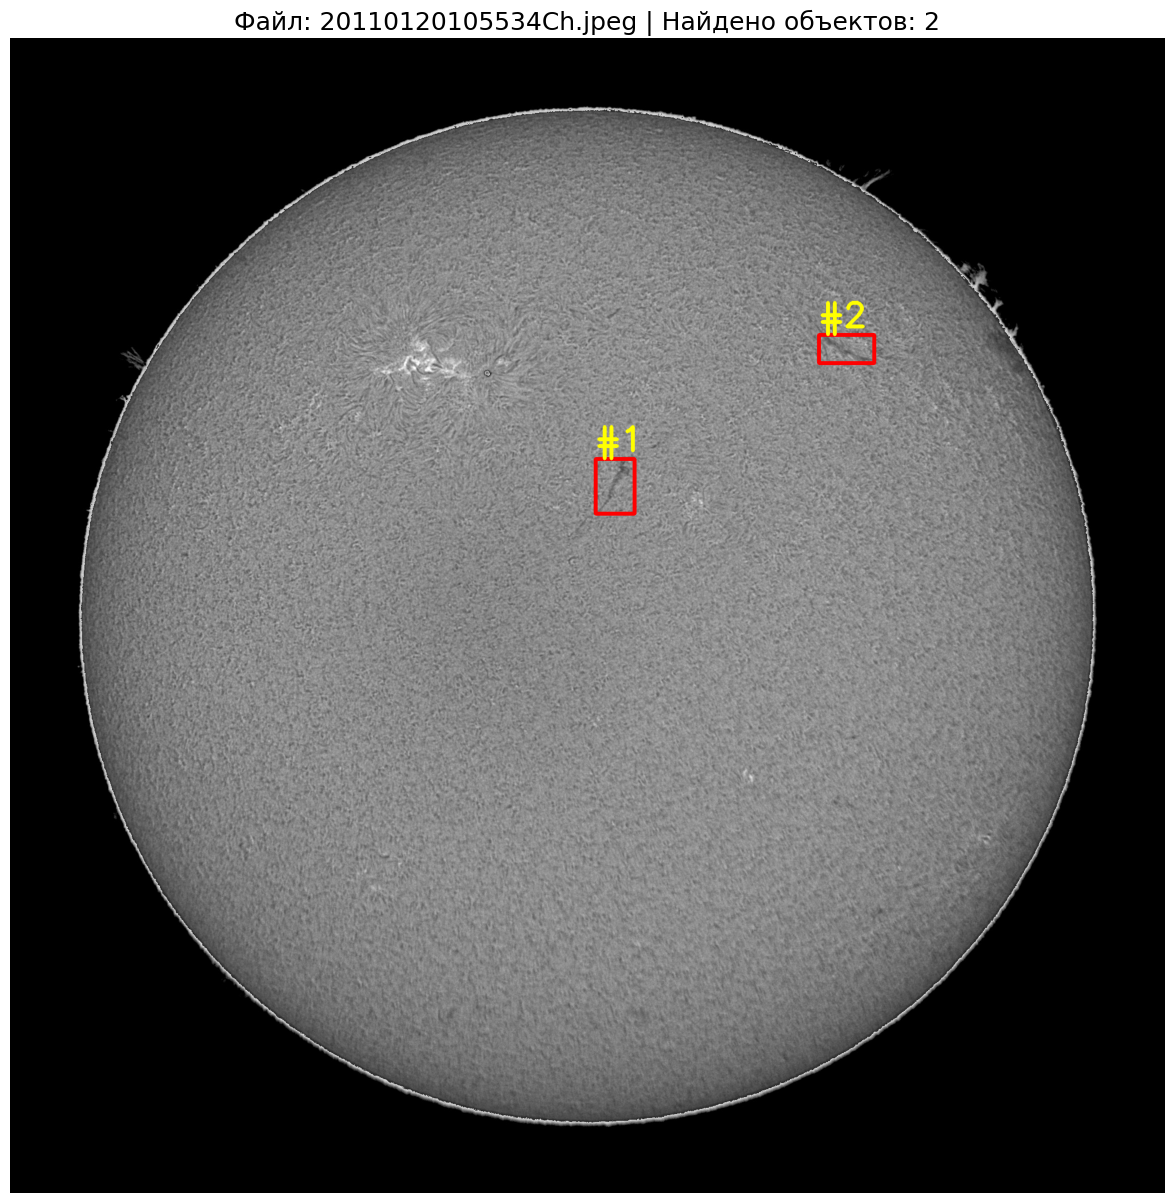

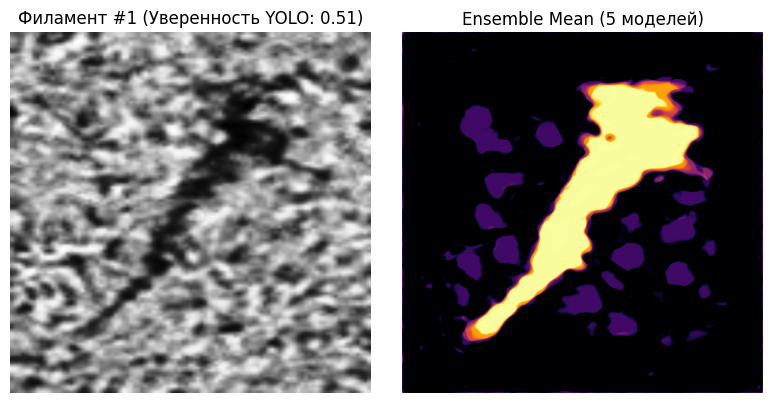

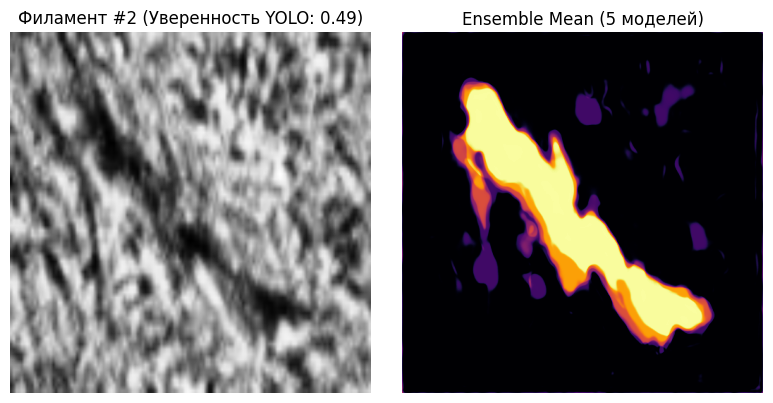

In [39]:
CFG_CROP_SIZE = 512
PAD_RATIO = 0.20
MAX_FILAMENTS = 15
# --- 3. ВЫБИРАЕМ ТЕСТОВОЕ ФОТО ---
test_files = [f for f in sorted(os.listdir(TEST_IMG_DIR)) if f.endswith(('.jpeg', '.jpg', '.png'))]
fname = test_files[0] # Можно поменять индекс, чтобы посмотреть другие фото
img_path = os.path.join(TEST_IMG_DIR, fname)

# --- 4. ПРЕДОБРАБОТКА И ДЕТЕКЦИЯ YOLO ---
raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if len(raw_img.shape) > 2: raw_img = raw_img[:, :, 0]
h, w = raw_img.shape[:2]

disk_mask = raw_img > 15
proc_img = raw_img.copy()
if np.any(disk_mask):
    proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
fused_img = np.stack([proc_img.astype(np.float32) / 255.0] * 3, axis=-1)

results = det_model.predict(img_path, imgsz=1280, conf=0.30, verbose=False)[0]
boxes = results.boxes.xyxy.cpu().numpy()
confs = results.boxes.conf.cpu().numpy()

# Сортируем по уверенности (сначала самые явные филаменты)
sorted_indices = np.argsort(-confs)
boxes = boxes[sorted_indices]
confs = confs[sorted_indices]

# --- 5. ОТРИСОВКА ОРИГИНАЛА С РАМКАМИ ---
img_color = cv2.cvtColor(raw_img, cv2.COLOR_GRAY2RGB)
for idx, (box, conf) in enumerate(zip(boxes, confs)):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_color, (x1, y1), (x2, y2), (255, 0, 0), 6)
    # Нумеруем рамки для удобства сопоставления с кропами ниже
    cv2.putText(img_color, f"#{idx+1}", (x1, max(y1 - 15, 20)), 
                cv2.FONT_HERSHEY_SIMPLEX, 2.0, (255, 255, 0), 5)

plt.figure(figsize=(15, 15))
plt.imshow(img_color)
plt.title(f"Файл: {fname} | Найдено объектов: {len(boxes)}", fontsize=18)
plt.axis('off')
plt.show()

# --- 6. ИНФЕРЕНС АНСАМБЛЯ И ОТРИСОВКА (ОРИГИНАЛ + СРЕДНЕЕ) ---
num_to_show = min(len(boxes), MAX_FILAMENTS)

for idx in range(num_to_show):
    box = boxes[idx]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    pw, ph = bw * PAD_RATIO, bh * PAD_RATIO
    cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
    cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
    
    crop = cv2.resize(fused_img[cy1:cy2, cx1:cx2], (CFG_CROP_SIZE, CFG_CROP_SIZE))
    batch = torch.from_numpy(crop).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    
    probs = []
    with torch.no_grad(), torch.amp.autocast('cuda'):
        for model in seg_models:
            p = torch.sigmoid(model(batch)).float().cpu().numpy()[0, 0]
            probs.append(p)
            
    # Усреднение 5 моделей
    ensemble_prob = np.mean(probs, axis=0)
    
    # Компактная отрисовка: 1 строка, 2 колонки для каждого филамента
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    axes[0].imshow(crop[:, :, 0], cmap='gray')
    axes[0].set_title(f"Филамент #{idx+1} (Уверенность YOLO: {confs[idx]:.2f})")
    axes[0].axis('off')
    
    axes[1].imshow(ensemble_prob, cmap='inferno', vmin=0, vmax=1)
    axes[1].set_title("Ensemble Mean (5 моделей)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [55]:
test_images = sorted([
    os.path.join(TEST_IMG_DIR, f)
    for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith(
        (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    )
])

print("\nTest images:", len(test_images))


# ============================================================
# LOAD YOLO
# ============================================================

print("\nLoading YOLO...")

yolo_model = YOLO(YOLO_WEIGHTS)

print("YOLO loaded.")


# ============================================================
# LOAD SEGMENTATION MODEL
# ============================================================

def load_segmentation_model(fold):

    model_path = os.path.join(
        SEG_MODEL_DIR,
        f"best_seg_resnet34_fold_{fold}.pth"
    )

    print("\nLoading segmentation model:")
    print(model_path)

    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=1
    )

    checkpoint = torch.load(
        model_path,
        map_location=DEVICE
    )

    # --------------------------------------------------------
    # Support both:
    # state_dict
    #
    # and:
    # {"model_state_dict": ...}
    # --------------------------------------------------------

    if (
        isinstance(checkpoint, dict)
        and "model_state_dict" in checkpoint
    ):
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)

    model.to(DEVICE)
    model.eval()

    return model


# ============================================================
# ROBUST IMAGE LOADING
# ============================================================

def load_grayscale_image(image_path):

    img = cv2.imread(
        image_path,
        cv2.IMREAD_UNCHANGED
    )

    if img is None:
        return None

    # --------------------------------------------------------
    # Already grayscale
    # (H, W)
    # --------------------------------------------------------

    if img.ndim == 2:
        return img

    # --------------------------------------------------------
    # Grayscale with explicit channel
    # (H, W, 1)
    # --------------------------------------------------------

    if img.ndim == 3 and img.shape[2] == 1:
        return img[:, :, 0]

    # --------------------------------------------------------
    # BGR
    # (H, W, 3)
    # --------------------------------------------------------

    if img.ndim == 3 and img.shape[2] == 3:

        return cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

    # --------------------------------------------------------
    # BGRA
    # (H, W, 4)
    # --------------------------------------------------------

    if img.ndim == 3 and img.shape[2] == 4:

        return cv2.cvtColor(
            img,
            cv2.COLOR_BGRA2GRAY
        )

    raise ValueError(
        f"Unexpected image shape: {img.shape}"
    )


# ============================================================
# PREPROCESS CROP FOR U-NET
# ============================================================

def preprocess_crop(crop):

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    crop_resized = cv2.resize(
        crop,
        (SEG_IMG_SIZE, SEG_IMG_SIZE),
        interpolation=cv2.INTER_LINEAR
    )

    # --------------------------------------------------------
    # CLAHE
    # --------------------------------------------------------

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    crop_resized = clahe.apply(
        crop_resized
    )

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    crop_resized = (
        crop_resized.astype(np.float32)
        / 255.0
    )

    # --------------------------------------------------------
    # Grayscale -> 3 channels
    #
    # (512,512)
    #       ↓
    # (3,512,512)
    # --------------------------------------------------------

    crop_resized = np.stack(
        [
            crop_resized,
            crop_resized,
            crop_resized
        ],
        axis=0
    )

    # --------------------------------------------------------
    # Tensor
    #
    # (3,512,512)
    #       ↓
    # (1,3,512,512)
    # --------------------------------------------------------

    tensor = torch.from_numpy(
        crop_resized
    ).float().unsqueeze(0)

    return tensor.to(DEVICE)


# ============================================================
# U-NET PREDICTION
# ============================================================

@torch.no_grad()
def predict_crop(model, crop):

    tensor = preprocess_crop(
        crop
    )

    logits = model(
        tensor
    )

    probability = torch.sigmoid(
        logits
    )

    probability = probability[
        0, 0
    ].cpu().numpy()

    return probability


# ============================================================
# RUN ONE FOLD
# ============================================================

def run_single_fold(fold):

    print("\n")
    print("=" * 70)
    print(f"RUNNING FOLD {fold}")
    print("=" * 70)

    # ========================================================
    # LOAD ONLY ONE U-NET
    # ========================================================

    seg_model = load_segmentation_model(
        fold
    )

    # ========================================================
    # IMPORTANT:
    # RESET SUBMISSION DATA
    # ========================================================

    submission_data = []

    # ========================================================
    # PROCESS TEST IMAGES
    # ========================================================

    for image_path in tqdm(
        test_images,
        desc=f"Fold {fold}"
    ):

        # ====================================================
        # IMAGE ID
        # ====================================================

        image_name = os.path.basename(
            image_path
        )

        image_id = os.path.splitext(
            image_name
        )[0]

        # ====================================================
        # READ IMAGE
        # ====================================================

        try:

            raw_img = load_grayscale_image(
                image_path
            )

        except Exception as e:

            print(
                f"\nWARNING: "
                f"{image_name}: {e}"
            )

            continue

        if raw_img is None:

            print(
                f"\nWARNING: "
                f"failed to read {image_name}"
            )

            continue

        # ====================================================
        # SHAPE
        # ====================================================

        H, W = raw_img.shape

        # ====================================================
        # SOLAR DISK MASK
        # ====================================================

        disk_mask = (
            raw_img > 15
        )

        # ====================================================
        # CLAHE
        # ====================================================

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

        enhanced = clahe.apply(
            raw_img
        )

        # ====================================================
        # REMOVE OFF-DISK REGION
        # ====================================================

        enhanced[
            ~disk_mask
        ] = 0

        # ====================================================
        # IMPORTANT:
        # YOLO EXPECTS 3 CHANNELS
        #
        # grayscale:
        # (H,W)
        #
        # ->
        #
        # BGR:
        # (H,W,3)
        # ====================================================

        yolo_input = cv2.cvtColor(
            enhanced,
            cv2.COLOR_GRAY2BGR
        )

        # ====================================================
        # YOLO DETECTION
        # ====================================================

        results = yolo_model.predict(

            source=yolo_input,

            imgsz=YOLO_IMGSZ,

            conf=YOLO_CONF,

            verbose=False,

            device=(
                0
                if DEVICE == "cuda"
                else "cpu"
            )
        )

        result = results[0]

        # ====================================================
        # NO DETECTIONS
        # ====================================================

        if (
            result.boxes is None
            or len(result.boxes) == 0
        ):
            continue

        # ====================================================
        # GET BOXES
        # ====================================================

        boxes = (
            result
            .boxes
            .xyxy
            .cpu()
            .numpy()
        )

        scores = (
            result
            .boxes
            .conf
            .cpu()
            .numpy()
        )

        # ====================================================
        # SORT BY YOLO CONFIDENCE
        # ====================================================

        order = np.argsort(
            -scores
        )

        boxes = boxes[order]
        scores = scores[order]

        # ====================================================
        # PANOPTIC PAINTING
        # ====================================================

        occupied_pixels = np.zeros(
            (H, W),
            dtype=np.uint8
        )

        # IMPORTANT:
        # this counts ONLY accepted predictions
        instance_counter = 0

        # ====================================================
        # PROCESS EVERY YOLO BOX
        # ====================================================

        for box_idx, box in enumerate(
            boxes
        ):

            # ------------------------------------------------
            # BOX COORDINATES
            # ------------------------------------------------

            x1, y1, x2, y2 = box

            x1 = int(
                np.floor(x1)
            )

            y1 = int(
                np.floor(y1)
            )

            x2 = int(
                np.ceil(x2)
            )

            y2 = int(
                np.ceil(y2)
            )

            # ------------------------------------------------
            # BOX SIZE
            # ------------------------------------------------

            box_w = x2 - x1
            box_h = y2 - y1

            if box_w <= 0 or box_h <= 0:
                continue

            # ------------------------------------------------
            # 20% PADDING
            # ------------------------------------------------

            pad_x = int(
                box_w * CROP_PADDING
            )

            pad_y = int(
                box_h * CROP_PADDING
            )

            x1_pad = max(
                0,
                x1 - pad_x
            )

            y1_pad = max(
                0,
                y1 - pad_y
            )

            x2_pad = min(
                W,
                x2 + pad_x
            )

            y2_pad = min(
                H,
                y2 + pad_y
            )

            # ------------------------------------------------
            # SAFETY
            # ------------------------------------------------

            if (
                x2_pad <= x1_pad
                or y2_pad <= y1_pad
            ):
                continue

            # =================================================
            # CROP ORIGINAL GRAYSCALE IMAGE
            # =================================================

            crop = raw_img[
                y1_pad:y2_pad,
                x1_pad:x2_pad
            ]

            if crop.size == 0:
                continue

            # =================================================
            # U-NET
            # =================================================

            probability = predict_crop(
                seg_model,
                crop
            )

            # =================================================
            # THRESHOLD
            # =================================================

            mask_512 = (
                probability >= MASK_THR
            ).astype(np.uint8)

            # =================================================
            # EMPTY MASK
            # =================================================

            if mask_512.sum() == 0:
                continue

            # =================================================
            # ORIGINAL CROP SIZE
            # =================================================

            crop_h = (
                y2_pad - y1_pad
            )

            crop_w = (
                x2_pad - x1_pad
            )

            # =================================================
            # RESIZE MASK BACK
            # =================================================

            mask_crop = cv2.resize(

                mask_512,

                (
                    crop_w,
                    crop_h
                ),

                interpolation=cv2.INTER_NEAREST
            )

            # =================================================
            # KEEP ONLY SOLAR DISK
            # =================================================

            local_disk_mask = disk_mask[
                y1_pad:y2_pad,
                x1_pad:x2_pad
            ]

            mask_crop[
                ~local_disk_mask
            ] = 0

            # =================================================
            # PANOPTIC PAINTING
            #
            # Higher YOLO confidence gets priority
            # =================================================

            local_occupied = occupied_pixels[
                y1_pad:y2_pad,
                x1_pad:x2_pad
            ]

            mask_crop[
                local_occupied > 0
            ] = 0

            # =================================================
            # EMPTY AFTER OVERLAP REMOVAL
            # =================================================

            if mask_crop.sum() == 0:
                continue

            # =================================================
            # FULL-SIZE MASK
            # =================================================

            full_mask = np.zeros(
                (H, W),
                dtype=np.uint8
            )

            full_mask[
                y1_pad:y2_pad,
                x1_pad:x2_pad
            ] = mask_crop

            # =================================================
            # UPDATE OCCUPIED PIXELS
            # =================================================

            occupied_pixels[
                y1_pad:y2_pad,
                x1_pad:x2_pad
            ][mask_crop > 0] = 1

            # =================================================
            # INSTANCE COUNTER
            # =================================================

            instance_counter += 1

            # =================================================
            # UNIQUE FILAMENT ID
            # =================================================

            filament_id = (
                f"{image_id}_"
                f"{instance_counter}"
            )

            # =================================================
            # RLE
            # =================================================

            rle = maskUtils.encode(
                np.asfortranarray(
                    full_mask
                )
            )

            rle_counts = rle["counts"]

            if isinstance(
                rle_counts,
                bytes
            ):
                rle_counts = (
                    rle_counts
                    .decode("utf-8")
                )

            # =================================================
            # ADD TO SUBMISSION
            # =================================================

            submission_data.append({

                "filament_id":
                    filament_id,

                "segmentation_rle":
                    rle_counts
            })

    # ========================================================
    # DATAFRAME
    # ========================================================

    submission_df = pd.DataFrame(

        submission_data,

        columns=[
            "filament_id",
            "segmentation_rle"
        ]
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    print("\n")
    print("-" * 70)
    print(f"FOLD {fold} SUMMARY")
    print("-" * 70)

    print(
        "Predicted instances:",
        len(submission_df)
    )

    if len(submission_df) > 0:

        unique_ids = (
            submission_df[
                "filament_id"
            ].nunique()
        )

        print(
            "Unique IDs:",
            unique_ids
        )

        # ----------------------------------------------------
        # Duplicate ID check
        # ----------------------------------------------------

        assert (
            unique_ids
            == len(submission_df)
        ), "DUPLICATE FILAMENT IDs!"

        # ----------------------------------------------------
        # Empty RLE check
        # ----------------------------------------------------

        assert not (
            submission_df[
                "segmentation_rle"
            ].isna()
        ).any(), "NaN RLE found!"

    # ========================================================
    # SAVE
    # ========================================================

    output_path = os.path.join(

        OUTPUT_DIR,

        f"submission_fold_{fold}.csv"
    )

    submission_df.to_csv(
        output_path,
        index=False
    )

    print(
        "\nSaved:",
        output_path
    )

    # ========================================================
    # CLEAN GPU
    # ========================================================

    del seg_model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return submission_df


# ============================================================
# RUN ALL 5 FOLDS
# ============================================================

all_fold_results = {}

for fold in range(5):

    df = run_single_fold(
        fold
    )

    all_fold_results[
        fold
    ] = df

    print(
        f"\nFold {fold} finished: "
        f"{len(df)} instances"
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("ALL 5 FOLDS FINISHED")
print("=" * 70)

for fold, df in all_fold_results.items():

    print(
        f"Fold {fold}: "
        f"{len(df)} predictions"
    )

print("\nOutput files:")

for fold in range(5):

    path = os.path.join(
        OUTPUT_DIR,
        f"submission_fold_{fold}.csv"
    )

    print(path)


Test images: 180

Loading YOLO...
YOLO loaded.


RUNNING FOLD 0

Loading segmentation model:
X:\Desktop\kaggle\solar_project_cv\models\best_seg_resnet34_fold_0.pth


C:\Users\User\AppData\Local\Temp\ipykernel_25376\3490085727.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(
Fold 0: 100%|██████████| 180/180 [0



----------------------------------------------------------------------
FOLD 0 SUMMARY
----------------------------------------------------------------------
Predicted instances: 1487
Unique IDs: 1487

Saved: X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_0.csv

Fold 0 finished: 1487 instances


RUNNING FOLD 1

Loading segmentation model:
X:\Desktop\kaggle\solar_project_cv\models\best_seg_resnet34_fold_1.pth


Fold 1: 100%|██████████| 180/180 [01:11<00:00,  2.53it/s]




----------------------------------------------------------------------
FOLD 1 SUMMARY
----------------------------------------------------------------------
Predicted instances: 1495
Unique IDs: 1495

Saved: X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_1.csv

Fold 1 finished: 1495 instances


RUNNING FOLD 2

Loading segmentation model:
X:\Desktop\kaggle\solar_project_cv\models\best_seg_resnet34_fold_2.pth


...



----------------------------------------------------------------------
FOLD 2 SUMMARY
----------------------------------------------------------------------
Predicted instances: 1497
Unique IDs: 1497

Saved: X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_2.csv

Fold 2 finished: 1497 instances


RUNNING FOLD 3

Loading segmentation model:
X:\Desktop\kaggle\solar_project_cv\models\best_seg_resnet34_fold_3.pth


Fold 3: 100%|██████████| 180/180 [01:08<00:00,  2.64it/s]




----------------------------------------------------------------------
FOLD 3 SUMMARY
----------------------------------------------------------------------
Predicted instances: 1497
Unique IDs: 1497

Saved: X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_3.csv

Fold 3 finished: 1497 instances


RUNNING FOLD 4

Loading segmentation model:
X:\Desktop\kaggle\solar_project_cv\models\best_seg_resnet34_fold_4.pth


Fold 4: 100%|██████████| 180/180 [01:09<00:00,  2.60it/s]



----------------------------------------------------------------------
FOLD 4 SUMMARY
----------------------------------------------------------------------
Predicted instances: 1497
Unique IDs: 1497

Saved: X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_4.csv

Fold 4 finished: 1497 instances


ALL 5 FOLDS FINISHED
Fold 0: 1487 predictions
Fold 1: 1495 predictions
Fold 2: 1497 predictions
Fold 3: 1497 predictions
Fold 4: 1497 predictions

Output files:
X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_0.csv
X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_1.csv
X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_2.csv
X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_3.csv
X:\Desktop\kaggle\solar_project_cv\submissions\submission_fold_4.csv


In [10]:
# --- 1. ПУТИ ДЛЯ KAGGLE ---
TEST_IMG_DIR = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"
# ВНИМАНИЕ: Укажи пути к загруженным файлам с весами в твоем Kaggle-датасете
YOLO_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\yolo_detector\weights\best.pt"
# SEG_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\best_seg_effnetb4.pth" 

SAVE_DIR = r"X:\Desktop\kaggle\solar_project_cv\models"

In [11]:
import os, cv2, torch, numpy as np, pandas as pd, segmentation_models_pytorch as smp
from ultralytics import YOLO
from pycocotools import mask as maskUtils
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
YOLO_CONF, YOLO_SIZE, PAD_RATIO, MASK_THR = 0.30, 1280, 0.20, 0.50
TEST_DIR = TEST_IMG_DIR  # твой путь к test
OUT_DIR = "ensemble_submissions"
os.makedirs(OUT_DIR, exist_ok=True)

yolo = YOLO(YOLO_WEIGHTS)
models = []
for fold in range(5):
    model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"best_seg_resnet34_fold_{fold}.pth"), map_location=DEVICE))
    model.eval()
    models.append(model)

methods = {
    "mean_all": lambda p: np.mean(p, axis=0),
    "mean_1_4": lambda p: np.mean(p[1:], axis=0),
    "mean_1_3": lambda p: np.mean(p[1:4], axis=0),
    "median": lambda p: np.median(p, axis=0),
    "trimmed": lambda p: np.mean(np.sort(p, axis=0)[1:-1], axis=0),
    "weighted": lambda p: np.average(p, axis=0, weights=np.array([0.15, 0.29, 0.27, 0.25, 0.22]) / np.sum([0.15, 0.29, 0.27, 0.25, 0.22]))
}
submissions = {k: [] for k in methods}

def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(path)
    if img.ndim == 3:
        img = img[:, :, 0] if img.shape[2] == 1 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

for fname in tqdm(sorted(os.listdir(TEST_DIR)), desc="Inference"):
    path = os.path.join(TEST_DIR, fname)
    raw = load_gray(path)
    H, W = raw.shape
    disk = raw > 15
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(raw.astype(np.uint8))
    enhanced[~disk] = 0
    yolo_img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
    result = yolo.predict(yolo_img, imgsz=YOLO_SIZE, conf=YOLO_CONF, verbose=False)[0]

    if len(result.boxes) == 0:
        continue

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    order = np.argsort(-confs)
    occupied = {k: np.zeros((H, W), np.uint8) for k in methods}
    instance_id = {k: 0 for k in methods}
    image_id = os.path.splitext(fname)[0]

    for bi in order:
        x1,y1,x2,y2 = boxes[bi].astype(int)
        bw,bh = x2-x1,y2-y1
        px,py = int(bw*PAD_RATIO), int(bh*PAD_RATIO)
        x1,y1,x2,y2 = max(0,x1-px), max(0,y1-py), min(W,x2+px), min(H,y2+py)
        crop = enhanced[y1:y2, x1:x2]
        if crop.size == 0: continue
        crop = cv2.resize(crop, (512,512), interpolation=cv2.INTER_AREA)
        crop = clahe.apply(crop).astype(np.float32)/255.0
        x = torch.from_numpy(np.stack([crop,crop,crop])).unsqueeze(0).float().to(DEVICE)

        probs = []
        with torch.inference_mode():
            for model in models:
                probs.append(torch.sigmoid(model(x))[0,0].cpu().numpy())
        probs = np.stack(probs)

        for name, agg_fn in methods.items():
            m = (agg_fn(probs) > MASK_THR).astype(np.uint8)
            ch,cw = y2-y1,x2-x1
            m = cv2.resize(m, (cw,ch), interpolation=cv2.INTER_NEAREST)
            m[~disk[y1:y2,x1:x2]] = 0
            full = np.zeros((H,W), np.uint8)
            full[y1:y2,x1:x2] = m
            full[occupied[name] > 0] = 0
            if full.sum() == 0: continue
            occupied[name][full > 0] = 1
            instance_id[name] += 1
            rle = maskUtils.encode(np.asfortranarray(full))
            rle["counts"] = rle["counts"].decode("utf-8")
            submissions[name].append({"filament_id": f"{image_id}_{instance_id[name]}", "segmentation_rle": rle["counts"]})

for name, data in submissions.items():
    df = pd.DataFrame(data, columns=["filament_id","segmentation_rle"])
    assert df.filament_id.is_unique
    out = os.path.join(OUT_DIR, f"submission_{name}.csv")
    df.to_csv(out, index=False)
    print(f"{name}: {len(df)} instances -> {out}")

C:\Users\User\AppData\Local\Temp\ipykernel_28704\2684012531.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"be

mean_all: 1496 instances -> ensemble_submissions\submission_mean_all.csv
mean_1_4: 1497 instances -> ensemble_submissions\submission_mean_1_4.csv
mean_1_3: 1496 instances -> ensemble_submissions\submission_mean_1_3.csv
median: 1497 instances -> ensemble_submissions\submission_median.csv
trimmed: 1497 instances -> ensemble_submissions\submission_trimmed.csv
weighted: 1497 instances -> ensemble_submissions\submission_weighted.csv


In [18]:
import os, cv2, numpy as np, pandas as pd
from ultralytics import YOLO
from tqdm import tqdm

YOLO_SIZE = 1280
CONF_THRESHOLDS = [0.10, 0.20, 0.30, 0.40, 0.50]
IOU_THR = 0.50

yolo = YOLO(YOLO_WEIGHTS)

def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(path)
    if img.ndim == 3:
        img = img[:, :, 0] if img.shape[2] == 1 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1, ix2, iy2 = max(ax1,bx1), max(ay1,by1), min(ax2,bx2), min(ay2,by2)
    inter = max(0,ix2-ix1) * max(0,iy2-iy1)
    if inter == 0: return 0.0
    aa = (ax2-ax1)*(ay2-ay1); ab = (bx2-bx1)*(by2-by1)
    return inter / (aa + ab - inter)

gt_by_image = {}
for ann in coco_data["annotations"]:
    x,y,w,h = ann["bbox"]
    gt_by_image.setdefault(ann["image_id"], []).append([x,y,x+w,y+h])

results = []

for fold in range(5):
    df_val = df_images[df_images["fold"] == fold].reset_index(drop=True)
    print(f"\nFOLD {fold}")

    for conf_thr in CONF_THRESHOLDS:
        TP = FP = FN = 0
        matched_ious = []

        for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc=f"conf={conf_thr}"):
            img = load_gray(os.path.join(train_img_dir, row["file_name"]))
            disk = img > 15
            clahe = cv2.createCLAHE(2.0, (8,8))
            enhanced = clahe.apply(img.astype(np.uint8))
            enhanced[~disk] = 0
            yolo_img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

            pred = yolo.predict(yolo_img, imgsz=YOLO_SIZE, conf=conf_thr, verbose=False)[0]
            pred_boxes = pred.boxes.xyxy.cpu().numpy().tolist() if len(pred.boxes) else []
            gt_boxes = gt_by_image.get(row["id"], [])

            pairs = [(iou(g,p), gi, pi) for gi,g in enumerate(gt_boxes) for pi,p in enumerate(pred_boxes)]
            pairs.sort(reverse=True)

            used_g, used_p = set(), set()
            for score, gi, pi in pairs:
                if score >= IOU_THR and gi not in used_g and pi not in used_p:
                    used_g.add(gi); used_p.add(pi); matched_ious.append(score)

            tp = len(used_g)
            TP += tp
            FP += len(pred_boxes) - tp
            FN += len(gt_boxes) - tp

        precision = TP / (TP + FP) if TP + FP else 0
        recall = TP / (TP + FN) if TP + FN else 0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
        mean_iou = np.mean(matched_ious) if matched_ious else 0

        results.append([fold, conf_thr, TP, FP, FN, precision, recall, f1, mean_iou])
        print(f"conf={conf_thr:.2f} | P={precision:.3f} R={recall:.3f} F1={f1:.3f} IoU={mean_iou:.3f}")

df_results = pd.DataFrame(results, columns=["fold","conf","TP","FP","FN","precision","recall","f1","mean_iou"])
print("\n", df_results.to_string(index=False))
# df_results.to_csv("yolo_validation_results.csv", index=False)


FOLD 0


conf=0.1: 100%|██████████| 142/142 [00:23<00:00,  6.03it/s]


conf=0.10 | P=0.434 R=0.631 F1=0.515 IoU=0.788


conf=0.2: 100%|██████████| 142/142 [00:22<00:00,  6.44it/s]


conf=0.20 | P=0.576 R=0.543 F1=0.559 IoU=0.793


...

conf=0.30 | P=0.682 R=0.489 F1=0.570 IoU=0.812


conf=0.4: 100%|██████████| 141/141 [00:21<00:00,  6.47it/s]


conf=0.40 | P=0.765 R=0.406 F1=0.531 IoU=0.824


conf=0.5: 100%|██████████| 141/141 [00:21<00:00,  6.48it/s]

conf=0.50 | P=0.844 R=0.319 F1=0.463 IoU=0.831

  fold  conf   TP   FP   FN  precision   recall       f1  mean_iou
    0   0.1 1023 1333  597   0.434211 0.631481 0.514588  0.787944
    0   0.2  880  649  740   0.575540 0.543210 0.558908  0.793404
    0   0.3  744  366  876   0.670270 0.459259 0.545055  0.801262
    0   0.4  604  228 1016   0.725962 0.372840 0.492659  0.806247
    0   0.5  471  123 1149   0.792929 0.290741 0.425474  0.815509
    1   0.1 1034 1275  552   0.447813 0.651955 0.530937  0.802469
    1   0.2  894  640  692   0.582790 0.563682 0.573077  0.809250
    1   0.3  760  352  826   0.683453 0.479193 0.563380  0.819215
    1   0.4  630  216  956   0.744681 0.397226 0.518092  0.830024
    1   0.5  473  116 1113   0.803056 0.298235 0.434943  0.842833
    2   0.1 1044 1326  616   0.440506 0.628916 0.518114  0.798197
    2   0.2  883  644  777   0.578258 0.531928 0.554126  0.805074
    2   0.3  736  378  924   0.660682 0.443373 0.530642  0.812633
    2   0.4  630  223 1030 

02.10

In [6]:
YOLO_PATH = r"X:\Desktop\kaggle\solar_project_cv\models\yolo_detector\weights\best.pt"
SAVE_DIR = r"X:\Desktop\kaggle\solar_project_cv\models"
TEST_DIR = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"

In [17]:
import os, cv2, torch, numpy as np, pandas as pd
import segmentation_models_pytorch as smp
from ultralytics import YOLO
from pycocotools import mask as maskUtils
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
YOLO_SIZE, PAD_RATIO, MASK_THR = 1280, 0.20, 0.50
CONF_TESTS = [0.35, 0.40]
OUT_DIR = "conf_test_submissions"
os.makedirs(OUT_DIR, exist_ok=True)

yolo = YOLO(YOLO_PATH)
models = []
for fold in range(5):
    m = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"best_seg_resnet34_fold_{fold}.pth"), map_location=DEVICE))
    m.eval()
    models.append(m)

subs = {c: [] for c in CONF_TESTS}
def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(path)
    if img.ndim == 3: img = img[:, :, 0] if img.shape[2] == 1 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

for fname in tqdm(sorted(os.listdir(TEST_DIR)), desc="Inference"):
    raw = load_gray(os.path.join(TEST_DIR, fname)); H, W = raw.shape
    disk = raw > 15
    clahe = cv2.createCLAHE(2.0, (8, 8))
    enhanced = clahe.apply(raw.astype(np.uint8)); enhanced[~disk] = 0
    yolo_img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
    r = yolo.predict(yolo_img, imgsz=YOLO_SIZE, conf=min(CONF_TESTS), verbose=False)[0]
    if len(r.boxes) == 0: continue
    boxes = r.boxes.xyxy.cpu().numpy(); confs = r.boxes.conf.cpu().numpy()
    order = np.argsort(-confs); image_id = os.path.splitext(fname)[0]
    occupied = {c: np.zeros((H,W), np.uint8) for c in CONF_TESTS}
    counters = {c: 0 for c in CONF_TESTS}

    for bi in order:
        det_conf = confs[bi]
        x1,y1,x2,y2 = boxes[bi].astype(int)
        bw,bh = x2-x1,y2-y1; px,py = int(bw*PAD_RATIO),int(bh*PAD_RATIO)
        x1,y1,x2,y2 = max(0,x1-px),max(0,y1-py),min(W,x2+px),min(H,y2+py)
        crop = enhanced[y1:y2,x1:x2]
        if crop.size == 0: continue

        crop512 = cv2.resize(crop,(512,512),interpolation=cv2.INTER_AREA)
        crop512 = clahe.apply(crop512).astype(np.float32)/255.0
        x = torch.from_numpy(np.stack([crop512,crop512,crop512])).unsqueeze(0).float().to(DEVICE)
        with torch.inference_mode():
            probs = np.stack([torch.sigmoid(m(x))[0,0].cpu().numpy() for m in models])
        mean_prob = probs.mean(axis=0)

        for conf_thr in CONF_TESTS:
            if det_conf < conf_thr: continue
            mask = (mean_prob > MASK_THR).astype(np.uint8)
            mask = cv2.resize(mask,(x2-x1,y2-y1),interpolation=cv2.INTER_NEAREST)
            mask[~disk[y1:y2,x1:x2]] = 0
            full = np.zeros((H,W),np.uint8); full[y1:y2,x1:x2] = mask
            full[occupied[conf_thr] > 0] = 0
            if full.sum() == 0: continue
            occupied[conf_thr][full > 0] = 1
            counters[conf_thr] += 1
            rle = maskUtils.encode(np.asfortranarray(full)); rle["counts"] = rle["counts"].decode("utf-8")
            subs[conf_thr].append({"filament_id":f"{image_id}_{counters[conf_thr]}","segmentation_rle":rle["counts"]})

for conf_thr,data in subs.items():
    df = pd.DataFrame(data, columns=["filament_id","segmentation_rle"])
    assert df["filament_id"].is_unique
    path = os.path.join(OUT_DIR,f"submission_conf_{str(conf_thr).replace('.','')}.csv")
    df.to_csv(path,index=False)
    print(f"conf={conf_thr}: {len(df)} instances -> {path}")

C:\Users\User\AppData\Local\Temp\ipykernel_13772\3131835252.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"best_s

conf=0.35: 1262 instances -> conf_test_submissions\submission_conf_035.csv
conf=0.4: 1096 instances -> conf_test_submissions\submission_conf_04.csv


In [8]:
import os, cv2, numpy as np
from ultralytics import YOLO
from tqdm import tqdm

In [10]:
def create_grouped_folds(coco_json_path, n_splits=5):
    with open(coco_json_path, "r") as f:
        coco_data = json.load(f)

    df_images = pd.DataFrame(coco_data["images"])
    df_images['group_date'] = df_images['file_name'].apply(lambda x: x[:8])

    gkf = GroupKFold(n_splits=n_splits)
    df_images["fold"] = -1

    for fold, (train_idx, val_idx) in enumerate(gkf.split(df_images, groups=df_images['group_date'])):
        df_images.loc[val_idx, 'fold'] = fold
        
    print(f"Dataset split into {n_splits} folds based on observation dates.")
    print(df_images['fold'].value_counts().sort_index())
    return df_images, coco_data

In [ ]:
import json
from sklearn.model_selection import GroupKFold

fused_json_path = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train_fused_deduplicated.json"
df_images, coco_data = create_grouped_folds(fused_json_path, n_splits=5)


Dataset split into 5 folds based on observation dates.
fold
0    142
1    142
2    141
3    141
4    141
Name: count, dtype: int64


In [15]:
train_img_dir = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\train\train_images"

In [16]:
CONF, IOU_THR, IMG_SIZE = 0.30, 0.50, 1280
OUT_DIR = "yolo_errors"
os.makedirs(OUT_DIR, exist_ok=True)
yolo = YOLO(YOLO_PATH)

def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None: raise ValueError(path)
    if img.ndim == 3: img = img[:,:,0] if img.shape[2] == 1 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def calc_iou(a,b):
    ax1,ay1,ax2,ay2=a; bx1,by1,bx2,by2=b
    ix1,iy1,ix2,iy2=max(ax1,bx1),max(ay1,by1),min(ax2,bx2),min(ay2,by2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    if inter==0:return 0
    return inter/((ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter)

gt_by_image={}
for a in coco_data["annotations"]:
    x,y,w,h=a["bbox"]
    gt_by_image.setdefault(a["image_id"],[]).append([x,y,x+w,y+h])

total_tp=total_fp=total_fn=0

for fold in range(5):
    df_val=df_images[df_images["fold"]==fold].reset_index(drop=True)
    fold_tp=fold_fp=fold_fn=0
    os.makedirs(f"{OUT_DIR}/fold_{fold}",exist_ok=True)

    for _,row in tqdm(df_val.iterrows(),total=len(df_val),desc=f"Fold {fold}"):
        path=os.path.join(train_img_dir,row["file_name"])
        img=load_gray(path); H,W=img.shape
        disk=img>15
        clahe=cv2.createCLAHE(2.0,(8,8))
        enhanced=clahe.apply(img.astype(np.uint8)); enhanced[~disk]=0
        yolo_img=cv2.cvtColor(enhanced,cv2.COLOR_GRAY2BGR)

        r=yolo.predict(yolo_img,imgsz=IMG_SIZE,conf=CONF,verbose=False)[0]
        preds=r.boxes.xyxy.cpu().numpy().tolist() if len(r.boxes) else []
        gts=gt_by_image.get(row["id"],[])

        pairs=sorted([(calc_iou(g,p),gi,pi) for gi,g in enumerate(gts) for pi,p in enumerate(preds)],reverse=True)
        used_g,used_p=set(),set(); matches=[]
        for iou,gi,pi in pairs:
            if iou>=IOU_THR and gi not in used_g and pi not in used_p:
                used_g.add(gi); used_p.add(pi); matches.append((gi,pi,iou))

        fn=[i for i in range(len(gts)) if i not in used_g]
        fp=[i for i in range(len(preds)) if i not in used_p]
        tp=len(matches)

        fold_tp+=tp; fold_fp+=len(fp); fold_fn+=len(fn)
        total_tp+=tp; total_fp+=len(fp); total_fn+=len(fn)

        if fn or fp:
            vis=cv2.cvtColor(enhanced,cv2.COLOR_GRAY2BGR)
            for gi,pi,_ in matches:
                x1,y1,x2,y2=map(int,gts[gi]); cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),3)
            for gi in fn:
                x1,y1,x2,y2=map(int,gts[gi]); cv2.rectangle(vis,(x1,y1),(x2,y2),(255,0,0),4)
            for pi in fp:
                x1,y1,x2,y2=map(int,preds[pi]); cv2.rectangle(vis,(x1,y1),(x2,y2),(0,0,255),4)
            cv2.putText(vis,f"TP:{tp} FN:{len(fn)} FP:{len(fp)}",(20,40),cv2.FONT_HERSHEY_SIMPLEX,1.2,(255,255,255),3)
            cv2.imwrite(f"{OUT_DIR}/fold_{fold}/{os.path.splitext(row['file_name'])[0]}_FN{len(fn)}_FP{len(fp)}.jpg",vis)

    print(f"Fold {fold}: TP={fold_tp} FP={fold_fp} FN={fold_fn}")

print(f"\nTOTAL: TP={total_tp} FP={total_fp} FN={total_fn}")
print(f"Precision={total_tp/(total_tp+total_fp):.4f}")
print(f"Recall={total_tp/(total_tp+total_fn):.4f}")

Fold 0: 100%|██████████| 142/142 [00:27<00:00,  5.08it/s]


Fold 0: TP=744 FP=366 FN=876


Fold 1: 100%|██████████| 142/142 [00:30<00:00,  4.60it/s]


Fold 1: TP=760 FP=352 FN=826


Fold 2: 100%|██████████| 141/141 [00:32<00:00,  4.39it/s]


Fold 2: TP=736 FP=378 FN=924


Fold 3: 100%|██████████| 141/141 [00:31<00:00,  4.45it/s]


Fold 3: TP=822 FP=311 FN=933


Fold 4: 100%|██████████| 141/141 [00:30<00:00,  4.61it/s]

Fold 4: TP=772 FP=360 FN=806

TOTAL: TP=3834 FP=1767 FN=4365
Precision=0.6845
Recall=0.4676
